Import Dependencies

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

Load Dataset

In [ ]:
df = pd.read_csv("bank-full.csv", sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.shape

(45211, 17)

In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Check Missing Values

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Check Target Variable

In [ ]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


Encode Categorical Columns

In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


Split Features and Target

In [ ]:
X = df.drop('y', axis=1)
y = df['y']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(36168, 16)
(9043, 16)


Build Decision Tree Model

In [ ]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Make Predictions

In [ ]:
y_pred = model.predict(X_test)

Calculate Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8935087913303107


Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



Confusion Matrix

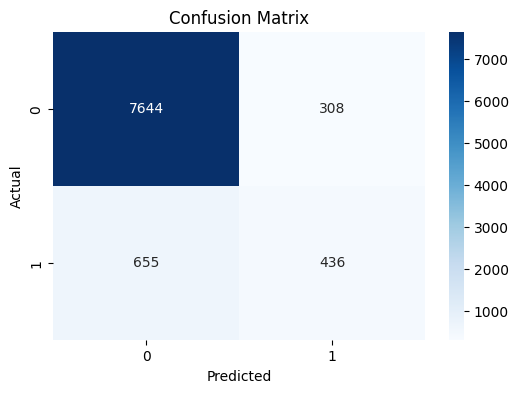

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Visualize Decision Tree

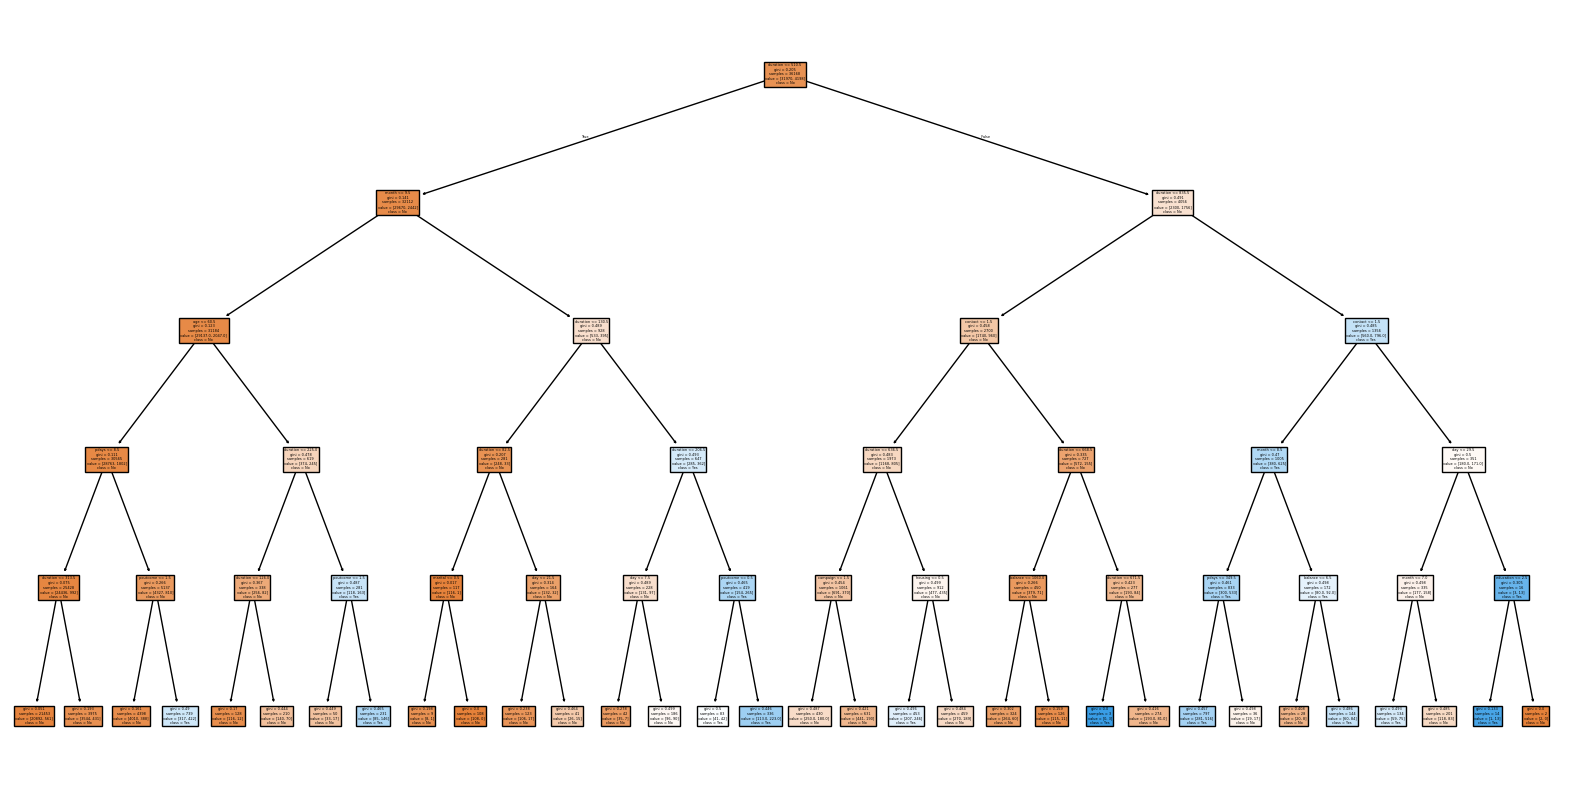

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

     Feature  Importance
11  duration    0.578134
15  poutcome    0.144215
10     month    0.113463
0        age    0.065036
13     pdays    0.057855
8    contact    0.023506
9        day    0.006439
6    housing    0.003712
12  campaign    0.003335
5    balance    0.002783


Plot Feature Importance

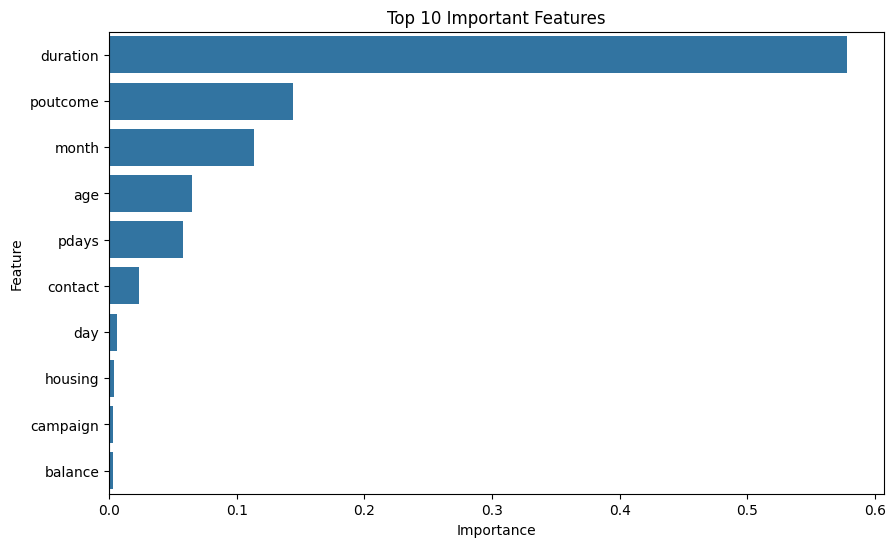

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

Save the Trained Model

In [ ]:
joblib.dump(model, "bank_marketing_decision_tree.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


Load Saved Model

In [ ]:
loaded_model = joblib.load(
    "bank_marketing_decision_tree.pkl"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


Test Saved Model

In [ ]:
sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(sample_prediction)

[0 0 0 0 0]


In [ ]:
print(X.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [ ]:
bank = pd.read_csv("bank-full.csv", sep=';')

for col in ['job','marital','education',
            'default','housing','loan',
            'contact','month','poutcome']:

    print("\n" + col.upper())
    print(bank[col].unique())


JOB
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

MARITAL
['married' 'single' 'divorced']

EDUCATION
['tertiary' 'secondary' 'unknown' 'primary']

DEFAULT
['no' 'yes']

HOUSING
['yes' 'no']

LOAN
['no' 'yes']

CONTACT
['unknown' 'cellular' 'telephone']

MONTH
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

POUTCOME
['unknown' 'failure' 'other' 'success']


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ['job','marital','education','default',
            'housing','loan','contact',
            'month','poutcome']:

    le = LabelEncoder()
    le.fit(bank[col])

    print(f"\n{col}")

    for i, cls in enumerate(le.classes_):
        print(i, "->", cls)


job
0 -> admin.
1 -> blue-collar
2 -> entrepreneur
3 -> housemaid
4 -> management
5 -> retired
6 -> self-employed
7 -> services
8 -> student
9 -> technician
10 -> unemployed
11 -> unknown

marital
0 -> divorced
1 -> married
2 -> single

education
0 -> primary
1 -> secondary
2 -> tertiary
3 -> unknown

default
0 -> no
1 -> yes

housing
0 -> no
1 -> yes

loan
0 -> no
1 -> yes

contact
0 -> cellular
1 -> telephone
2 -> unknown

month
0 -> apr
1 -> aug
2 -> dec
3 -> feb
4 -> jan
5 -> jul
6 -> jun
7 -> mar
8 -> may
9 -> nov
10 -> oct
11 -> sep

poutcome
0 -> failure
1 -> other
2 -> success
3 -> unknown


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


0.8935087913303107
